In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

In [2]:
antoine_data = {
    "Water": {
        "formula": "H₂O", "cas": "7732-18-5",
        "A": 4.65430, "B": 1435.264, "C": -64.848,
        "T_min": 255.9, "T_max": 373.0,
        "color": "#1f77b4", "linestyle": "-"
    },
    "Methanol": {
        "formula": "CH₃OH", "cas": "67-56-1",
        "A": 5.24677, "B": 1598.673, "C": -46.424,
        "T_min": 292.77, "T_max": 366.63,
        "color": "#ff7f0e", "linestyle": "-"
    },
    "Ethanol": {
        "formula": "C₂H₅OH", "cas": "64-17-5",
        "A": 5.37229, "B": 1670.409, "C": -40.191,
        "T_min": 273.0, "T_max": 351.70,
        "color": "#2ca02c", "linestyle": "-"
    },
    "Benzene": {
        "formula": "C₆H₆", "cas": "71-43-2",
        "A": 4.72583, "B": 1660.652, "C": -1.461,
        "T_min": 280.0, "T_max": 377.0,
        "color": "#d62728", "linestyle": "-"
    },
    "Toluene": {
        "formula": "C₇H₈", "cas": "108-88-3",
        "A": 4.07827, "B": 1343.943, "C": -53.773,
        "T_min": 308.0, "T_max": 384.0,
        "color": "#9467bd", "linestyle": "-"
    },
    "n-Hexane": {
        "formula": "C₆H₁₄", "cas": "110-54-3",
        "A": 3.82489, "B": 1492.928, "C": -55.895,
        "T_min": 219.7, "T_max": 307.73,
        "color": "#8c564b", "linestyle": "-"
    },
    "Propane": {
        "formula": "C₃H₈", "cas": "74-98-6",
        "A": 4.53678, "B": 1149.360, "C": 24.906,
        "T_min": 277.6, "T_max": 360.8,
        "color": "#e377c2", "linestyle": "-"
    },
    "n-Nonane": {
        "formula": "C₉H₂₀", "cas": "111-84-2",
        "A": 4.06245, "B": 1430.377, "C": -71.355,
        "T_min": 343.49, "T_max": 424.94,
        "color": "#7f7f7f", "linestyle": "-"
    },
    "Propiophenone": {
        "formula": "C₉H₁₀O", "cas": "93-55-0",
        "A": 5.16378, "B": 2430.732, "C": -18.595,
        "T_min": 405.36, "T_max": 474.47,
        "color": "#bcbd22", "linestyle": "-"
    }
}

In [3]:
def antoine_function(A, B, C, T):
    Psat = 10**(A - B/(C + T))
    return Psat

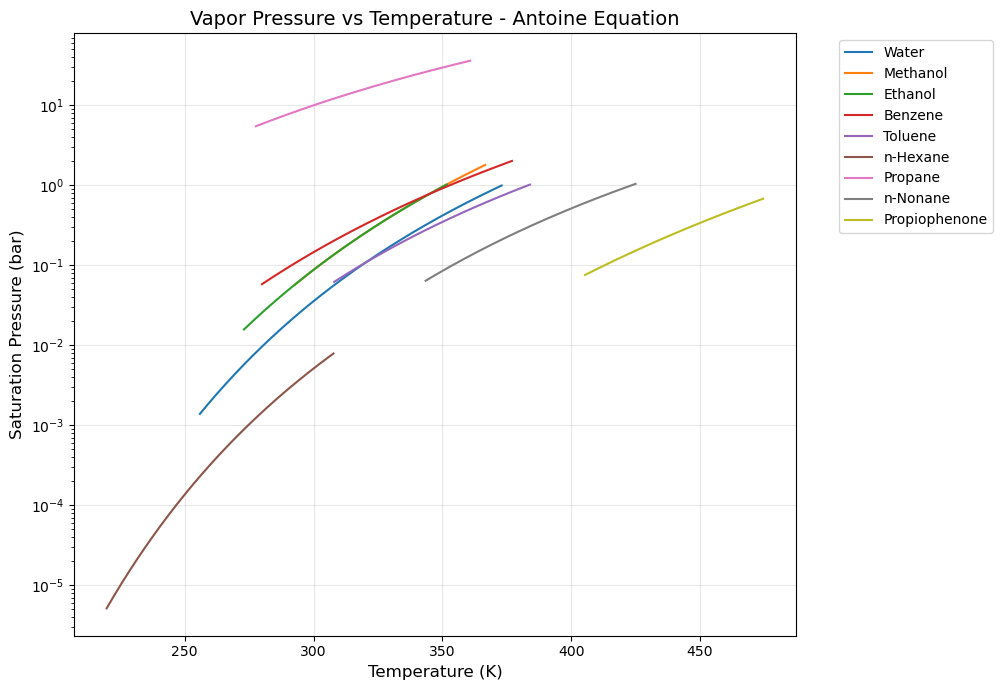

In [4]:
plt.figure(figsize=(10, 7))

for name, data in antoine_data.items():
    T_array = np.linspace(data["T_min"], data["T_max"], 300)
    Psat_array = antoine_function(data["A"], data["B"], data["C"], T_array)
    plt.plot(T_array, Psat_array, 
             label=name, 
             color=data["color"], 
             linestyle=data["linestyle"])

plt.xlabel("Temperature (K)", fontsize=12)
plt.ylabel("Saturation Pressure (bar) — log scale", fontsize=12)
plt.title("Vapor Pressure vs Temperature - Antoine Equation", fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.yscale("log")
plt.show()

In [5]:
P_input = float(input("enter a pressure value in bar"))
print(f"\n{'Compound':<15} | {'Boiling Point (K)':<18} | {'Status'}")
print("-" * 50)
for i, data in antoine_data.items():
    def diff(T):
        return antoine_function(data["A"], data["B"], data["C"], T) - P_input
    try:
        T_bp = brentq(diff, data["T_min"], data["T_max"])
        print(f"{i:<15} | {T_bp:>18.2f} K | Verified")   
    except ValueError:
        print(f"{i:<15} | {'Out of Range':>18} | out of range")

enter a pressure value in bar 0.57



Compound        | Boiling Point (K)  | Status
--------------------------------------------------
Water           |             357.85 K | Verified
Methanol        |             337.57 K | Verified
Ethanol         |             337.61 K | Verified
Benzene         |             335.60 K | Verified
Toluene         |             364.70 K | Verified
n-Hexane        |       Out of Range | out of range
Propane         |       Out of Range | out of range
n-Nonane        |             403.49 K | Verified
Propiophenone   |             468.07 K | Verified
